# Load dataset from kaggle using kagglehub

In [1]:
import kagglehub

path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")

100%|██████████| 511k/511k [00:00<00:00, 3.71MB/s]

Extracting model files...


# Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Load dataset


In [3]:
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")

# View distribution of device categories in training data


In [4]:
data_train.device_category.value_counts()

device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64

# View distribution of device categories in testing data


In [5]:
data_test.device_category.value_counts()

device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

# Combine training and testing data for unified processing


In [6]:
data = pd.concat([data_train, data_test], axis=0, ignore_index=True)
data.shape

(1900, 298)

# Shuffle the dataset to remove ordering bias


In [7]:
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,motion_sensor
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,TV
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,security_camera


# Check for missing values in the dataset


Text(0.5, 1.0, 'Total Missing Values')

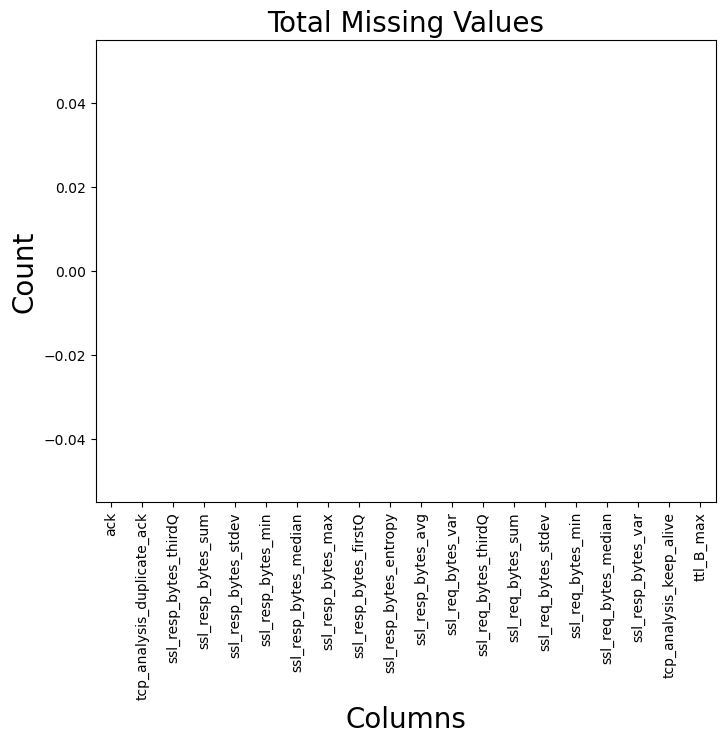

In [8]:
total = data.isnull().sum().sort_values(ascending=False)
total_select = total.head(20)
total_select.plot(kind="bar", figsize = (8,6), fontsize = 10)
plt.xlabel("Columns", fontsize = 20)
plt.ylabel("Count", fontsize = 20)
plt.title("Total Missing Values", fontsize = 20)

# Import LabelEncoder for encoding categorical features


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['device_category'] = le.fit_transform(data['device_category'])
data['device_category'].value_counts()

device_category
3    200
0    200
8    200
4    200
2    200
5    200
1    200
6    200
7    200
9    100
Name: count, dtype: int64

# Display the first few rows of the combined dataset


In [10]:
data.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,3
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,0
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,8
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,8
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,4


# Visualize correlation matrix to understand feature relationships


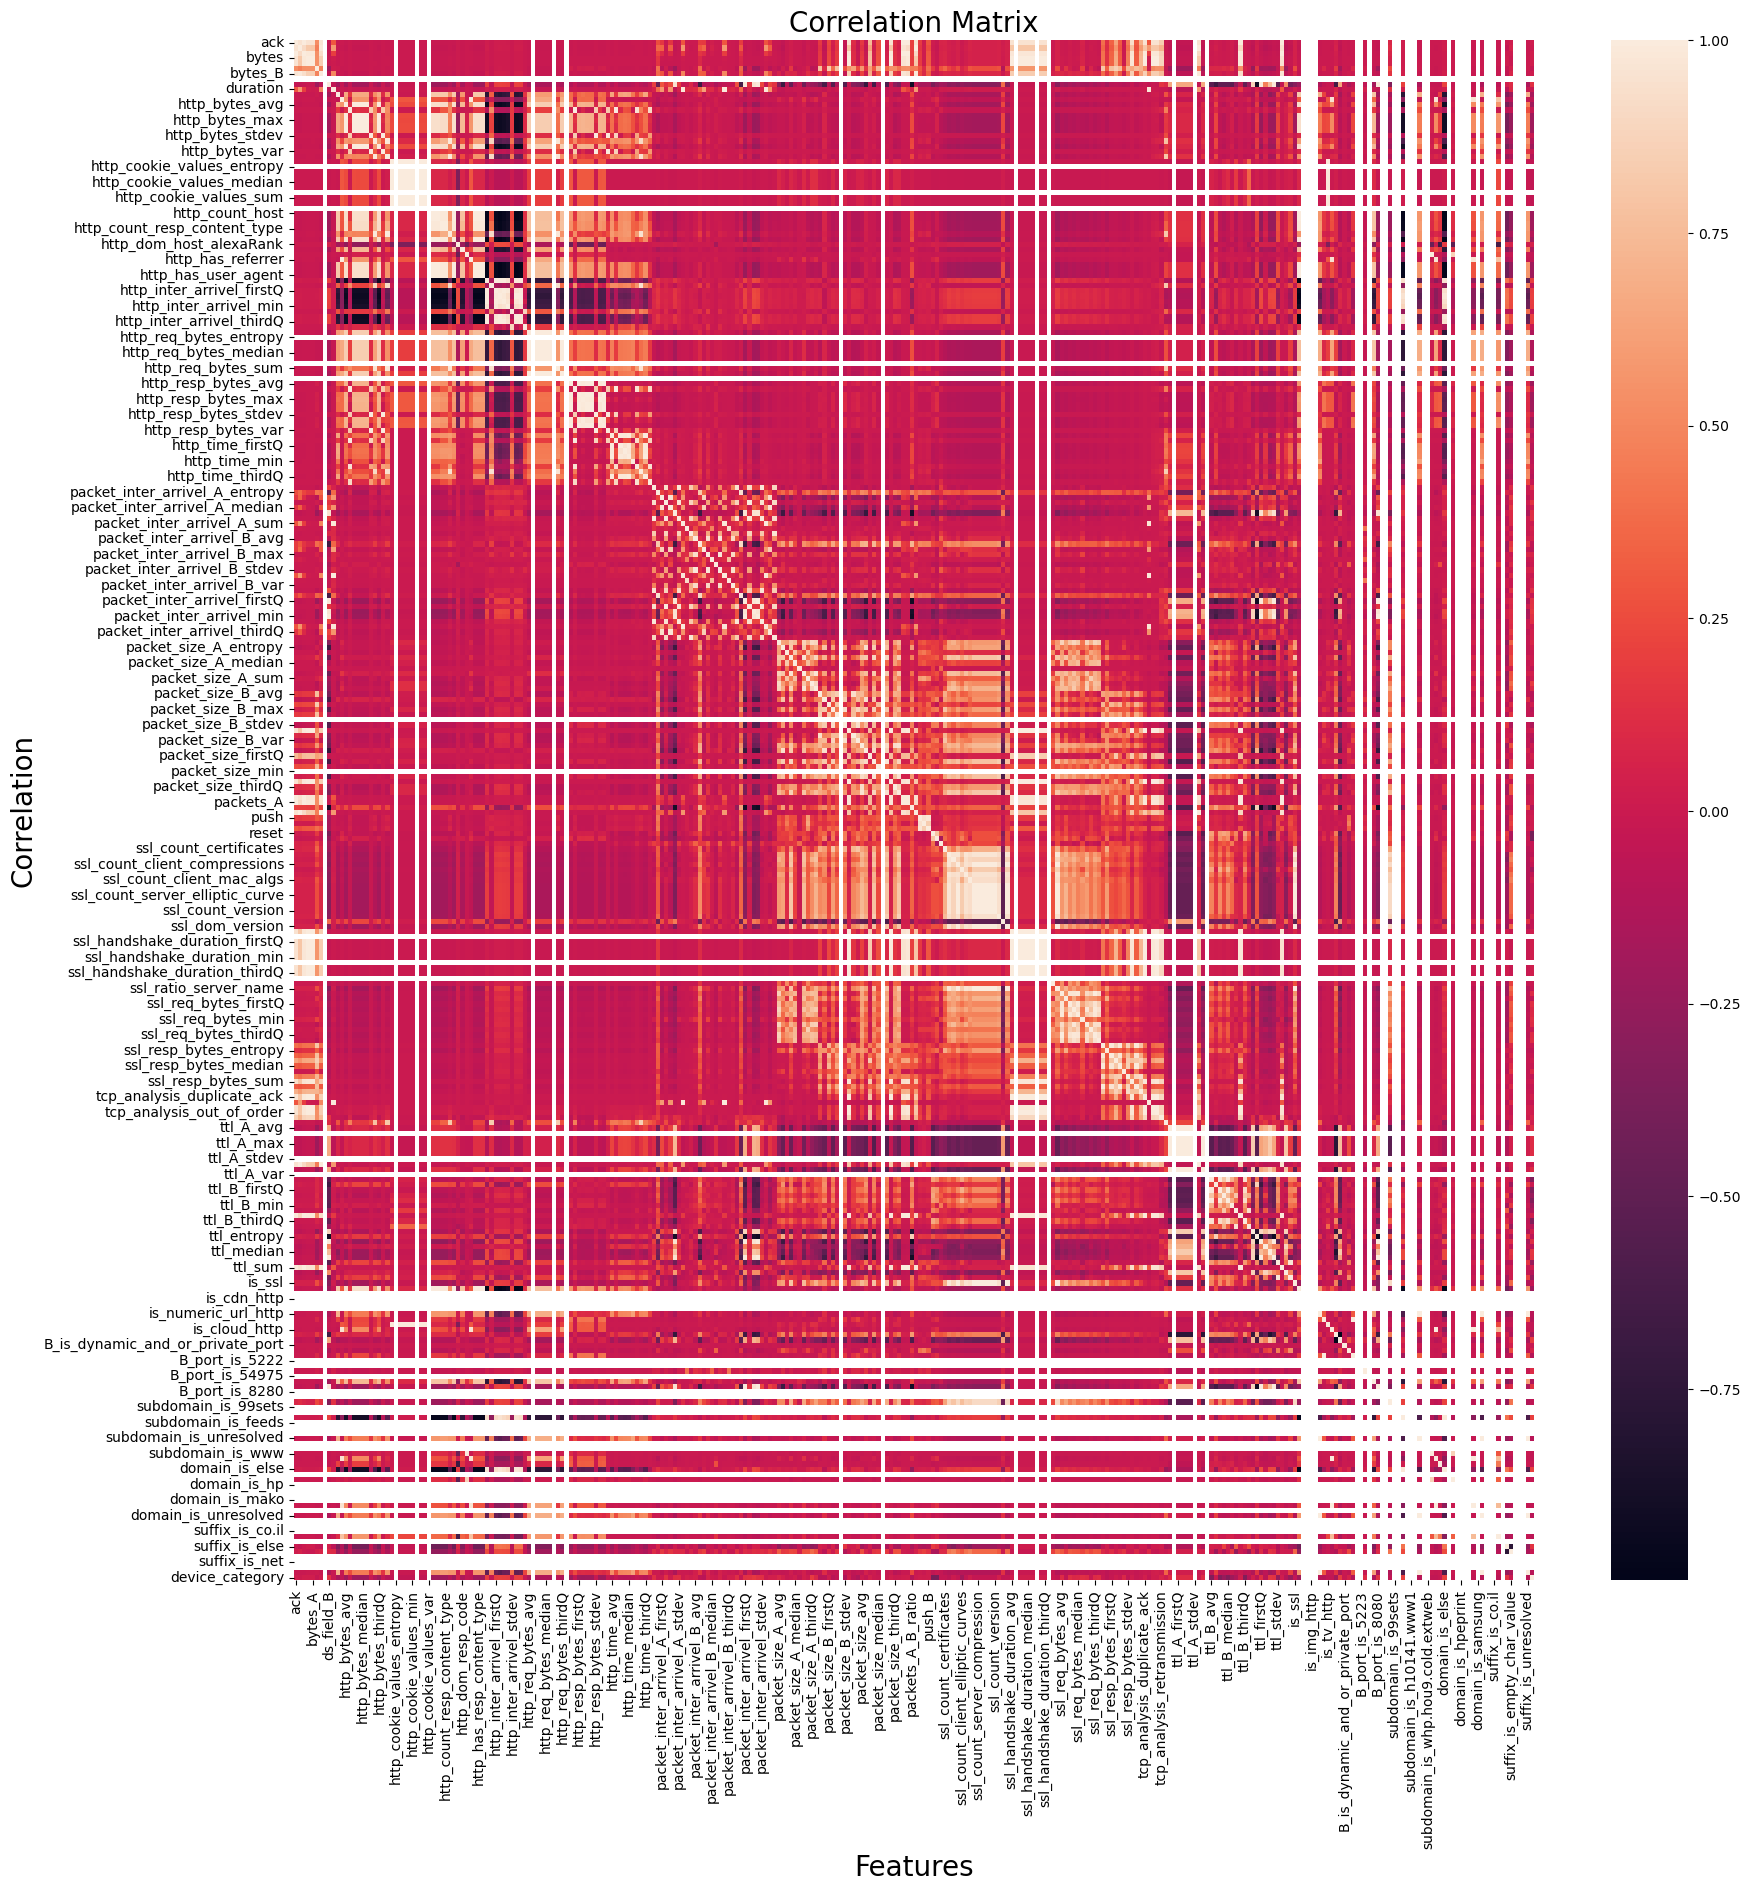

In [11]:
plt.figure(figsize=(20, 20))
sns.heatmap(data=data.corr())
plt.title("Correlation Matrix", fontsize = 20)
plt.xlabel("Features", fontsize = 20)
plt.ylabel("Correlation", fontsize = 20)
plt.show()

# Sort features by absolute correlation with the target variable


In [12]:
corr = data.corr().abs()['device_category'].sort_values(ascending=False)
drop_cols = corr[corr < 0.1].index
drop_cols

Index(['ssl_req_bytes_median', 'ttl_B_var', 'http_time_max',
       'packet_size_B_avg', 'http_time_thirdQ', 'http_time_avg',
       'http_time_median', 'packet_size_B_max', 'http_time_firstQ',
       'packet_inter_arrivel_B_firstQ',
       ...
       'packets_B', 'ack_A', 'packet_size_avg', 'packet_size_thirdQ',
       'packet_inter_arrivel_A_firstQ', 'ssl_count_client_ciphersuites',
       'packet_inter_arrivel_A_entropy', 'packet_size_A_sum', 'ttl_B_entropy',
       'packet_size_A_max'],
      dtype='object', length=160)

# Drop selected low-correlation or unnecessary features


In [13]:
data = data.drop(drop_cols, axis=1)
data.shape

(1900, 138)

# Split dataset into features (X) and target variable (y)


In [14]:
X = data.drop(columns=["device_category"])
y = data["device_category"]

# Normalize feature data using StandardScaler


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train XGBoost classifier on the training data

In [17]:
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:16:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Import classification metrics to evaluate model performance


              precision    recall  f1-score   support

           0       0.91      0.97      0.94        31
           1       1.00      1.00      1.00        36
           2       0.70      0.68      0.69        34
           3       1.00      0.98      0.99        41
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        40
           6       0.66      0.69      0.68        36
           7       0.92      0.98      0.95        49
           8       0.98      0.88      0.92        48
           9       0.64      0.64      0.64        22

    accuracy                           0.90       380
   macro avg       0.88      0.88      0.88       380
weighted avg       0.90      0.90      0.90       380



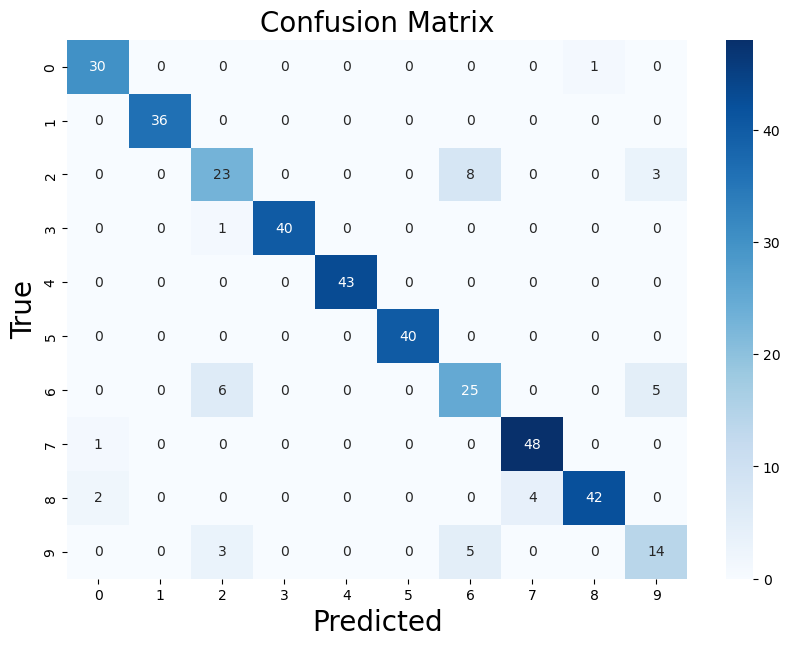

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        31
           1       1.00      1.00      1.00        36
           2       0.70      0.68      0.69        34
           3       1.00      0.98      0.99        41
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        40
           6       0.66      0.69      0.68        36
           7       0.92      0.98      0.95        49
           8       0.98      0.88      0.92        48
           9       0.64      0.64      0.64        22

    accuracy                           0.90       380
   macro avg       0.88      0.88      0.88       380
weighted avg       0.90      0.90      0.90       380



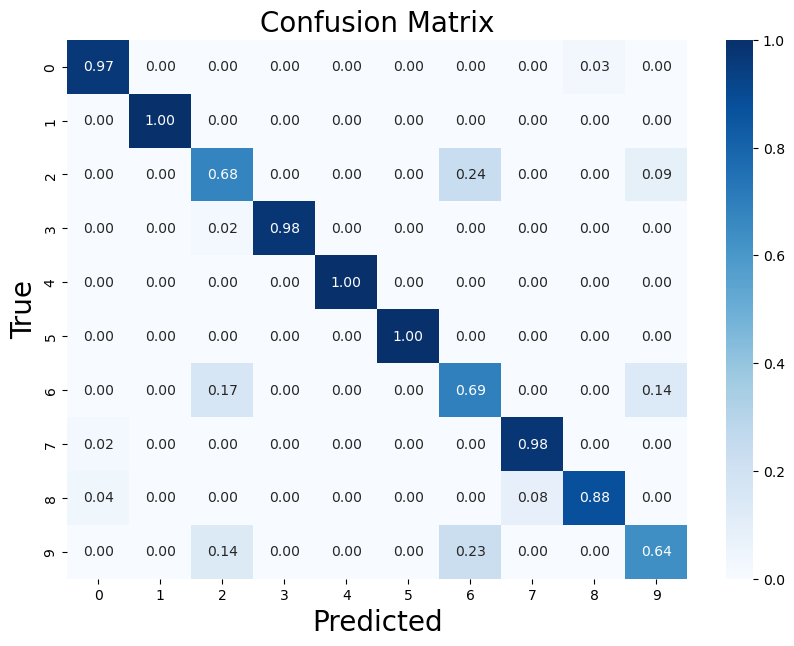

In [24]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()

<h3>Lazy classifier as a point of comparison</h3>

In [19]:
from lazypredict.Supervised import LazyClassifier

In [20]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

 97%|█████████▋| 31/32 [00:21<00:00,  3.89it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5191
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 90
[LightGBM] [Info] Start training from score -2.196567
[LightGBM] [Info] Start training from score -2.226599
[LightGBM] [Info] Start training from score -2.214478
[LightGBM] [Info] Start training from score -2.257561
[LightGBM] [Info] Start training from score -2.270220
[LightGBM] [Info] Start training from score -2.251292
[LightGBM] [Info] Start training from score -2.226599
[LightGBM] [Info] Start training from score -2.309186
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.969757
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

100%|██████████| 32/32 [00:23<00:00,  1.38it/s]

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
XGBClassifier                      0.90               0.89    None      0.90   
LGBMClassifier                     0.89               0.87    None      0.89   
RandomForestClassifier             0.89               0.87    None      0.89   
ExtraTreesClassifier               0.88               0.85    None      0.88   
BaggingClassifier                  0.86               0.84    None      0.86   
DecisionTreeClassifier             0.85               0.83    None      0.85   
LabelPropagation                   0.84               0.81    None      0.83   
LabelSpreading                     0.84               0.81    None      0.83   
ExtraTreeClassifier                0.84               0.81    None      0.84   
KNeighborsClassifier               0.83               0.81    None      0.83   
LogisticRegression                 0.82 

<h3>Decission tree</h3>

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [45]:
model_dt = DecisionTreeClassifier(max_depth=15)
model_dt.fit(X_train, y_train)
print("Accuracy during training:", model_dt.score(X_train, y_train))

Accuracy during training: 0.9993421052631579


In [46]:
predictions_dt = model_dt.predict(X_test)

              precision    recall  f1-score   support

           0       0.69      0.87      0.77        31
           1       0.97      0.94      0.96        36
           2       0.62      0.62      0.62        34
           3       0.97      0.95      0.96        41
           4       1.00      1.00      1.00        43
           5       1.00      1.00      1.00        40
           6       0.64      0.69      0.67        36
           7       0.94      0.94      0.94        49
           8       0.90      0.77      0.83        48
           9       0.65      0.59      0.62        22

    accuracy                           0.86       380
   macro avg       0.84      0.84      0.84       380
weighted avg       0.86      0.86      0.86       380



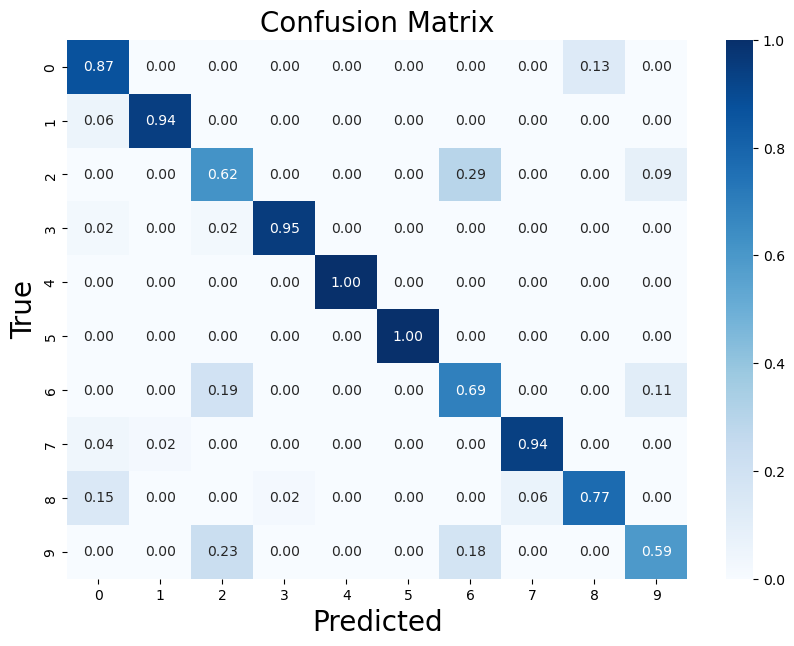

In [47]:
print(classification_report(y_test, predictions_dt))
cm = confusion_matrix(y_test, predictions_dt, normalize='true')
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()

<h3>Logistic regression</h3>

In [36]:
from sklearn.linear_model import LogisticRegression

In [48]:
model_lr = LogisticRegression(max_iter=10000)
model_lr.fit(X_train, y_train)
print("Accuracy during training:", model_lr.score(X_train, y_train))

Accuracy during training: 0.8282894736842106


In [49]:
predictions_lr = model_lr.predict(X_test)

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        31
           1       1.00      0.92      0.96        36
           2       0.47      0.82      0.60        34
           3       0.98      0.98      0.98        41
           4       0.83      1.00      0.91        43
           5       1.00      1.00      1.00        40
           6       0.48      0.31      0.37        36
           7       0.96      0.94      0.95        49
           8       0.92      0.73      0.81        48
           9       0.82      0.41      0.55        22

    accuracy                           0.81       380
   macro avg       0.81      0.79      0.78       380
weighted avg       0.83      0.81      0.81       380



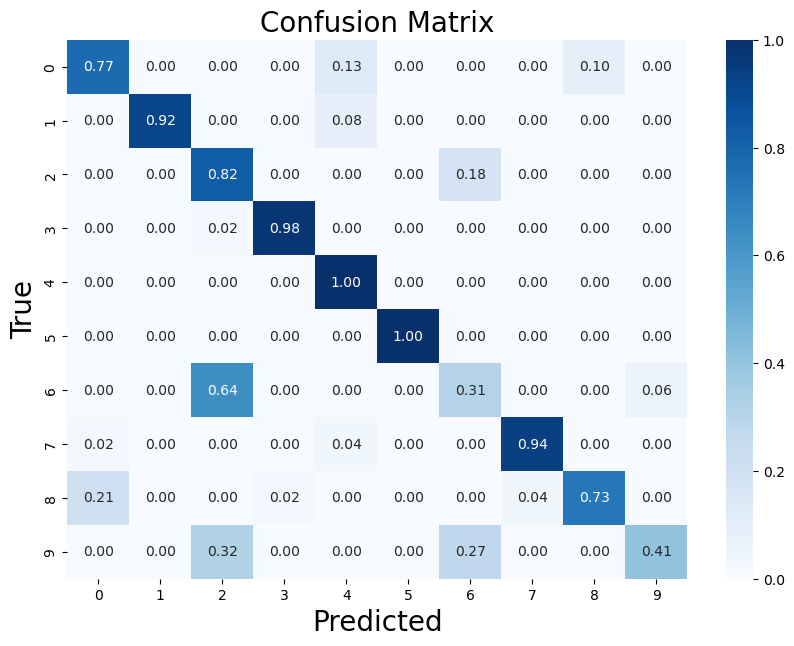

In [50]:
print(classification_report(y_test, predictions_lr))
cm = confusion_matrix(y_test, predictions_lr, normalize='true')
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.show()